# K-Means Clustering Algorithm

## Overview
K-Means is an unsupervised learning algorithm that partitions data into K clusters
by minimizing the within-cluster sum of squares (inertia)

## Key Concepts:
1. Centroid: The center point of a cluster
2. Inertia: Sum of squared distances from points to their nearest centroid
3. Convergence: Algorithm stops when centroids stop moving

## Steps:
1. Initialize K centroids randomly
2. Assign each point to nearest centroid
3. Update centroids as mean of assigned points
4. Repeat steps 2-3 until convergence

In [ ]:
# Elbow Method: Find optimal number of clusters by plotting inertia vs number of clusters


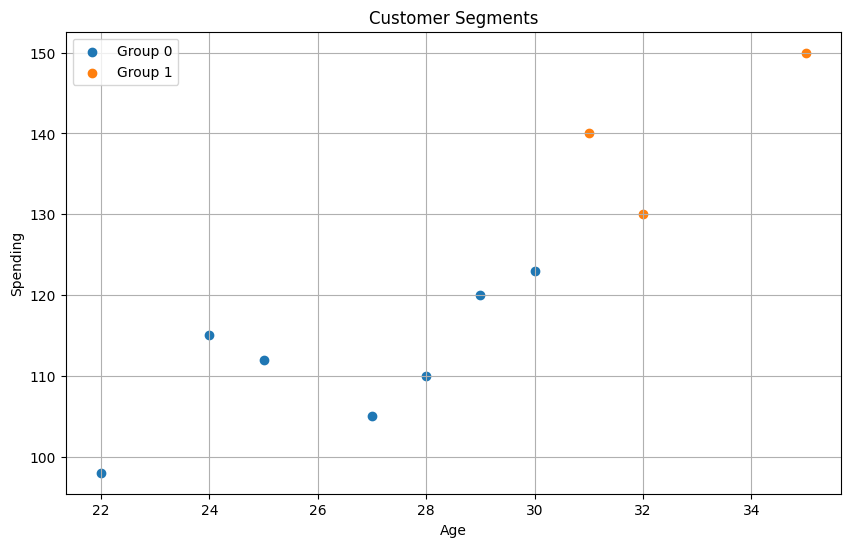

  customer  age  spending  Group
0     Riya   25       112      0
1     Aman   30       123      0
2   Faizan   22        98      0
3     Neha   28       110      0
4    Imran   35       150      1
5     Sana   27       105      0
6    Rahul   32       130      1
7   Anjali   24       115      0
8   Vikram   29       120      0
9    Pooja   31       140      1


In [ ]:
import pandas as pd
import sklearn.cluster as cluster
import matplotlib.pyplot as plt

#@sample data
data = {
    'customer': ['Riya', 'Aman', 'Faizan', 'Neha', 'Imran', 'Sana', 'Rahul', 'Anjali', 'Vikram', 'Pooja'],
    'age': [25, 30, 22, 28, 35, 27, 32, 24, 29, 31],
    'spending': [112, 123, 98, 110, 150, 105, 130, 115, 120, 140]
}

df = pd.DataFrame(data)
X = df[['age', 'spending']]

#@clustering
# random_state :- is set for reproducibility, n_init is set to 10 to specify the number of times the 
# algorithm will be run with different centroid seeds

# n_clusters :- is set to 2, which means we want to group the customers into 2 clusters based on their age and spending patterns.

# n_init :- is set to 10, which means the KMeans algorithm will be run 10 times with different initial centroid seeds, 
# and the best result will be chosen based on the lowest inertia (sum of squared distances to the nearest cluster center).

# The KMeans algorithm will attempt to find the best centroids for these clusters and assign each customer to the nearest cluster based on their features.
# Create a KMeans model with 2 clusters
model = cluster.KMeans(n_clusters=2, random_state=42, n_init=10)


df['Group'] = model.fit_predict(X)
plt.figure(figsize=(10, 6))

for group in df['Group'].unique(): # Iterate through each unique group
    group_data = df[df['Group'] == group] # Filter the data for the current group
    plt.scatter(group_data['age'], group_data['spending'], label=f'Group {group}') # Plot the data points for the current group

plt.xlabel('Age')
plt.ylabel('Spending')
plt.title('Customer Segments')
plt.legend()
plt.grid()
plt.show()
print(df)

# The Elbow Method is a technique to find the optimal number of clusters (K)

# How it works:
1. Run K-Means for different values of K (1 to 10 in your case)
2. For each K, calculate the inertia (sum of squared distances from points to their nearest centroid)
3. Plot inertia vs K value
4. Look for the "elbow" point - where inertia starts decreasing more slowly

# Why it's useful:
- Inertia always decreases as K increases (more clusters = smaller distances)
- The elbow point represents the optimal balance between cluster number and model fit
- Adding more clusters beyond the elbow provides minimal improvement

# In your case:
- K=1: Inertia = 2446.2 (all points in one cluster)
- K=2: Inertia = 701.24 (significant drop - this is the elbow!)
- K=3: Inertia = 316.13 (smaller improvement)
- K=10: Inertia = 0.0 (each point is its own cluster)

# Conclusion: 
K=2 is optimal for your customer data because the inertia drops sharply,
then the improvement rate slows down for K≥3

In [ ]:


print("Inertias list shows the elbow pattern:")
print(f"Inertias: {inertias}")
print(f"\nNotice the steep drop from K=1 to K=2, then slower improvements after K=2")
print(f"This indicates K=2 is the optimal number of clusters for your customer dataset")

Inertias list shows the elbow pattern:
Inertias: [2446.2, 701.2380952380954, 316.1333333333333, 173.66666666666666, 115.66666666666667, 63.33333333333333, 23.0, 10.0, 5.0, 0.0]

Notice the steep drop from K=1 to K=2, then slower improvements after K=2
This indicates K=2 is the optimal number of clusters for your customer dataset


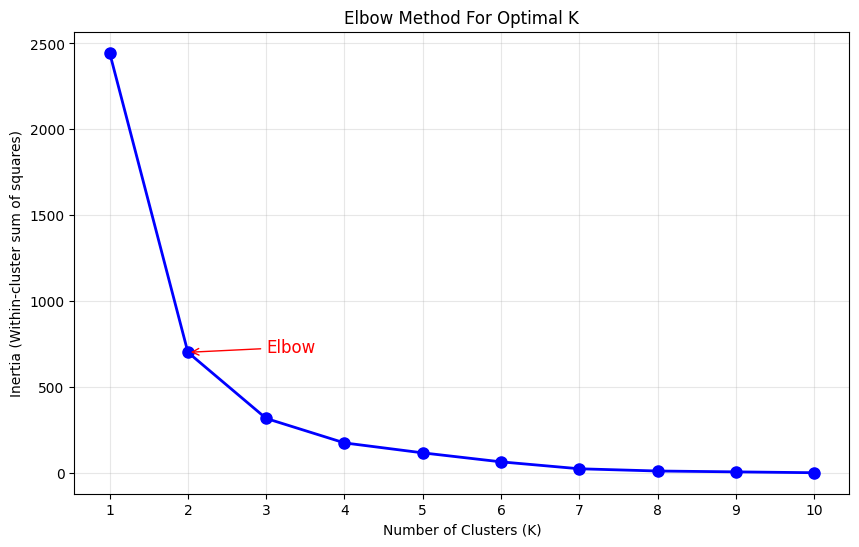

Inertia values for each K:
K=1: Inertia=2446.20
K=2: Inertia=701.24
K=3: Inertia=316.13
K=4: Inertia=173.67
K=5: Inertia=115.67
K=6: Inertia=63.33
K=7: Inertia=23.00
K=8: Inertia=10.00
K=9: Inertia=5.00
K=10: Inertia=0.00


In [ ]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = cluster.KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow Method For Optimal K')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)

# Mark the elbow point (typically at K=2 or K=3)
plt.annotate('Elbow', xy=(2, inertias[1]), xytext=(3, inertias[1]),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=12, color='red')
plt.show()

print("Inertia values for each K:")
for k, inertia in zip(K_range, inertias):
    print(f"K={k}: Inertia={inertia:.2f}")


## Principal Component Analysis (PCA) - Definition, Benefits, and Visualization
# DEFINITION:
PCA is an unsupervised dimensionality reduction technique that:
1. Transforms high-dimensional data into lower-dimensional space
2. Identifies principal components (directions of maximum variance)
3. Preserves as much variance as possible in fewer dimensions
4. Projects data onto new axes (principal components) that are orthogonal

# KEY CONCEPTS:
- Variance: Spread of data points along a direction
- Principal Components: New axes ordered by variance (PC1 > PC2 > PC3...)
- Loadings: Contributions of original features to principal components

# BENEFITS
1. Dimensionality Reduction: Reduces number of features while retaining information
2. Visualization: Enables visualization of high-dimensional data in 2D/3D
3. Removes Multicollinearity: Uncorrelated principal components
4. Noise Reduction: Focuses on directions with high variance
5. Computational Efficiency: Faster model training with fewer dimensions
6. Feature Extraction: Creates new meaningful features from original ones

PRINCIPAL COMPONENT ANALYSIS (PCA)




BENEFITS OF PCA
1. Dimensionality Reduction: Reduces number of features while retaining information
2. Visualization: Enables visualization of high-dimensional data in 2D/3D
3. Removes Multicollinearity: Uncorrelated principal components
4. Noise Reduction: Focuses on directions with high variance
5. Computational Efficiency: Faster model training with fewer dimensions
6. Feature Extraction: Creates new meaningful features from original ones

APPLYING PCA TO CUSTOMER DATA

Original data shape: (10, 2)
PCA-transformed data shape: (10, 2)

Explained Variance Ratio: [0.94519288 0.05480712]
Total Variance Explained: 100.00%

PC1 explains 94.52% of variance
PC2 explains 5.48% of variance

Feature Loadings (contribution to principal components):
               PC1       PC2
Age       0.707107  0.707107
Spending  0.707107 -0.707107

PCA VISUALIZATION


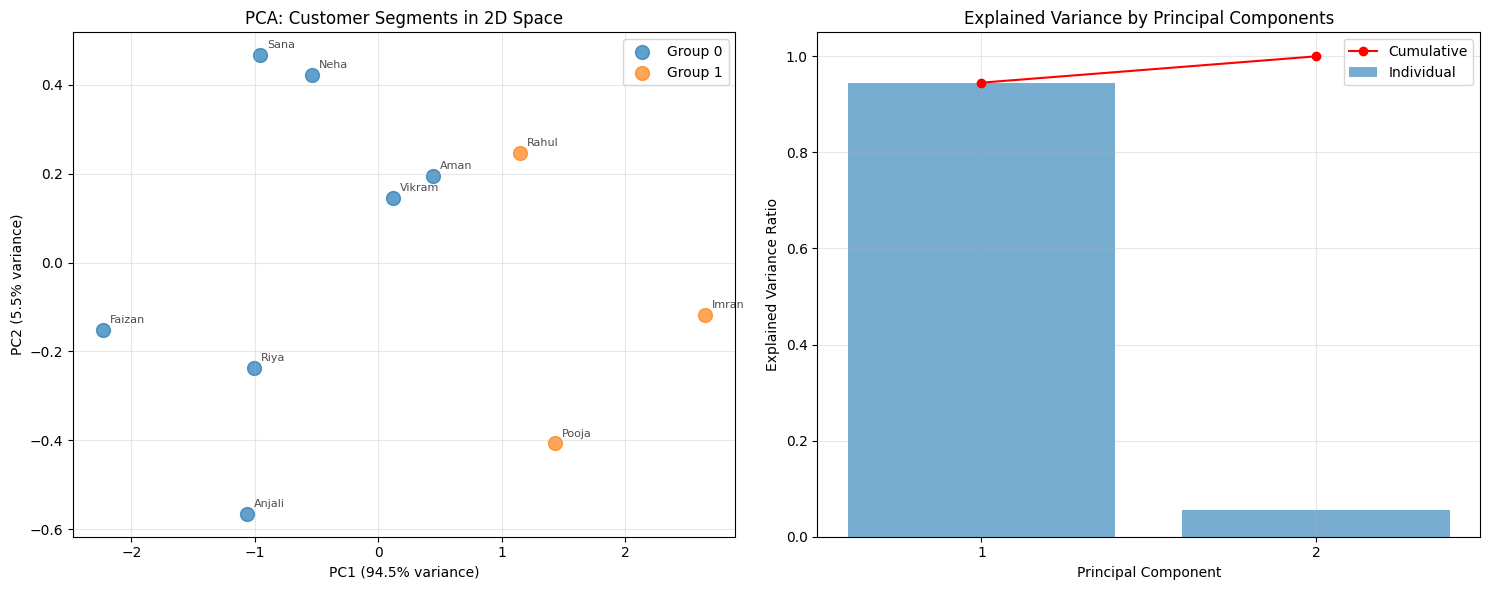


PCA successfully reduces 2D data while preserving cluster separation!


In [ ]:
from sklearn.decomposition import PCA
import numpy as np
from sklearn.preprocessing import StandardScaler




# APPLY PCA TO YOUR DATA
print("\n" + "=" * 60)
print("APPLYING PCA TO CUSTOMER DATA")
print("=" * 60)

# Standardize the data (important for PCA)

scaler = StandardScaler() # StandardScaler standardizes features by removing the mean and scaling to unit variance.
X_scaled = scaler.fit_transform(X)

# Apply PCA with 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"\nOriginal data shape: {X.shape}")
print(f"PCA-transformed data shape: {X_pca.shape}")
print(f"\nExplained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Variance Explained: {sum(pca.explained_variance_ratio_):.2%}")
print(f"\nPC1 explains {pca.explained_variance_ratio_[0]:.2%} of variance")
print(f"PC2 explains {pca.explained_variance_ratio_[1]:.2%} of variance")

# Show feature loadings
print("\nFeature Loadings (contribution to principal components):")
loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=['Age', 'Spending']
)
print(loadings_df)

# VISUALIZATION OF PCA
print("\n" + "=" * 60)
print("PCA VISUALIZATION")
print("=" * 60)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: PCA scatter plot colored by clusters
ax1 = axes[0]
for group in df['Group'].unique():
    mask = df['Group'] == group
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               label=f'Group {group}', s=100, alpha=0.7)

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax1.set_title('PCA: Customer Segments in 2D Space')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add customer names to points
for i, customer in enumerate(df['customer']):
    ax1.annotate(customer, (X_pca[i, 0], X_pca[i, 1]), 
                fontsize=8, alpha=0.7, xytext=(5, 5), 
                textcoords='offset points')

# Plot 2: Explained variance
ax2 = axes[1]
pca_full = PCA()
pca_full.fit(X_scaled)
cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)

ax2.bar(range(1, len(pca_full.explained_variance_ratio_) + 1), 
       pca_full.explained_variance_ratio_, alpha=0.6, label='Individual')
ax2.plot(range(1, len(cumsum_variance) + 1), cumsum_variance, 
        'ro-', label='Cumulative')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Explained Variance Ratio')
ax2.set_title('Explained Variance by Principal Components')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(1, 3))

plt.tight_layout()
plt.show()

print("\nPCA successfully reduces 2D data while preserving cluster separation!")

PCA applied successfully! Here are the PCA components:
[[ 0.48712618  0.50008004  0.50618893  0.50636036]
 [ 0.84366656 -0.46231451 -0.25317712 -0.10194786]]
Explained Variance Ratio: [0.95906311 0.03100646]

PCA Components (loadings):
[95.91  3.1 ]

Explained Variance Ratio: [0.95906311 0.03100646]


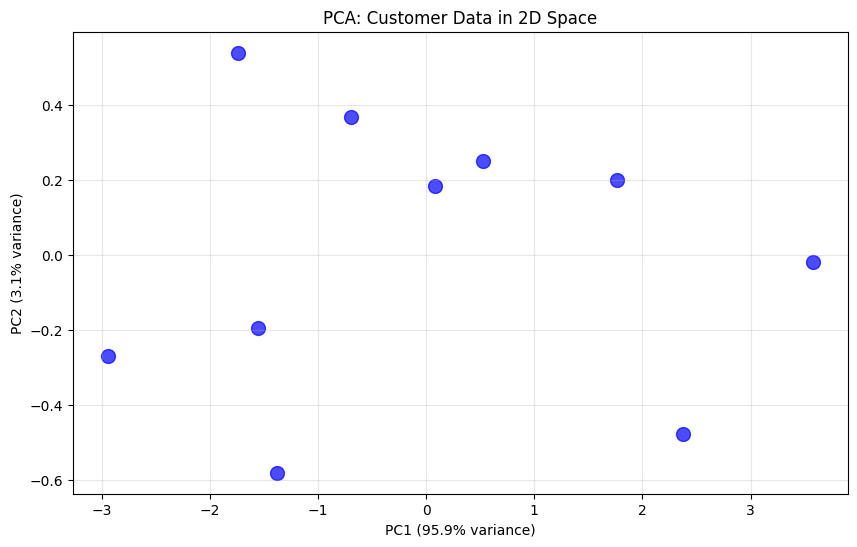

       PCA1      PCA2
0 -1.558788 -0.194554
1  0.521265  0.249125
2 -2.943798 -0.270321
3 -0.700670  0.368313
4  3.575255 -0.017892
5 -1.742436  0.539037
6  1.769139  0.200802
7 -1.376720 -0.580971
8  0.078910  0.184744
9  2.377841 -0.478284


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn.preprocessing as preprocessing
import sklearn.decomposition as decomposition

data = {
    'Age': [25, 30, 22, 28, 35, 27, 32, 24, 29, 31],
    'Spending': [112, 123, 98, 110, 150 , 105, 130, 115, 120, 140],
    'Income': [50000, 60000, 45000, 55000, 80000, 48000, 70000, 52000, 58000, 75000],
    'Savings': [20000, 30000, 15000, 25000, 40000, 18000, 35000, 22000, 28000, 38000]
}

df = pd.DataFrame(data)
scaler = preprocessing.StandardScaler()
X_scaled = scaler.fit_transform(df)
pca = decomposition.PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data=X_pca, columns=['PCA1', 'PCA2'])
explained_variance = pca.explained_variance_ratio_
print("PCA applied successfully! Here are the PCA components:")
print(pca.components_)
print(f"Explained Variance Ratio: {explained_variance}")
print("\nPCA Components (loadings):")
print(np.round(explained_variance*100, 2)) # Show percentage of variance explained by each principal component

print(f"\nExplained Variance Ratio: {pca.explained_variance_ratio_}")
plt.figure(figsize=(10, 6))
plt.scatter(pca_df['PCA1'], pca_df['PCA2'], color='blue', s=100, alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA: Customer Data in 2D Space')
plt.grid(True, alpha=0.3)
plt.show()

print(pca_df)
